[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/Entornos_Complejos/MonteCarloTodasLasVisitas.ipynb)

## **1. Deep Q-Learning para el entorno Frozen Lake**

In [ ]:
# %%capture
!pip install gymnasium
!pip install matplotlib tqdm numpy torch
!pip install "gymnasium[toy-text]"



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

from src.experiment.deep_functions import pi_star_from_Q, train_dqn, plot, plot_episodes_length, plot_policy_episodes

In [3]:
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU
# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla
# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python
# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

name = 'FrozenLake-v1' # Cambiar según el entorno deseado


Usando dispositivo: cpu


In [4]:
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi", reward_schedule=(1, 0, 0)) # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi", reward_schedule=(1, 0, 0)) # No resbaladizo para entender mejor los resultados.
env4.reset(seed=seed)
env8.reset(seed=seed)

(0, {'prob': 1})

## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
   - **Política epsilon-greedy**: De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
   - **Política greedy**: Es la usada una vez que "ha aprendido", eligiendo siempre la acción que maximiza el valor Q estimado por la red neuronal.

- **Algoritmo de Iteración de Valor**
  - Se implementa el algoritmo de Deep Q-Learning utilizando una red neuronal para aproximar la función de valor acción Q(s,a).
  - La red neuronal recibe como entrada el estado (codificado mediante embedding) y produce un valor Q para cada acción posible.
  - Se utiliza un buffer de replay (memoria de repetición de experiencias) para almacenar transiciones (estado, acción, recompensa, próximo estado, terminado) y romper las correlaciones temporales.
  - El aprendizaje se realiza mediante muestreo aleatorio de lotes del buffer de replay y actualización de los pesos de la red neuronal mediante descenso de gradiente para minimizar el error cuadrático medio entre los valores Q predichos y los objetivos calculados usando la ecuación de Bellman.
  - El objetivo (target) se calcula como: Qₜₐᵣ₉ₑₜ = R + γ × maxₐ' Q(s', a') donde γ es el factor de descuento.

#### **Código de las políticas y algoritmo MC**
----------------

## **3. Experimentación**  

In [ ]:
#Se realizan entrenamientos de 5000 pasos por motivos de computación y tiempo necesario.
Q_net, list_stats, list_episodes_length = train_dqn(
    env4, 
    num_episodes=5000, 
    epsilon=0.2,
    decay = True,
    discount_factor=0.99)

 10%|█         | 520/5000 [00:07<00:34, 131.03it/s]

success: 0.516, epsilon: 0.1996007984031936


 19%|█▉        | 962/5000 [00:10<00:26, 152.04it/s]

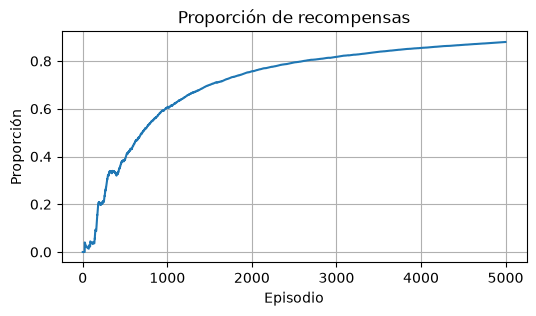

Máxima proporcion: 0.8798


In [ ]:
plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

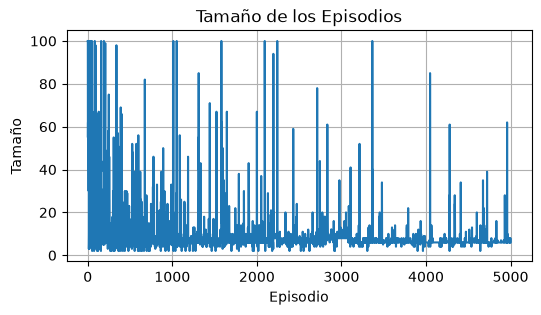

Máximo tamaño de episodio: 100


In [ ]:
plot_episodes_length(list_episodes_length)
print(f"Máximo tamaño de episodio:", max(list_episodes_length))

In [ ]:
pi, actions = pi_star_from_Q(env4, Q_net)
print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())

Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones 2, 2, 1, 1, 1, 2,  
 Para el siguiente grid
   (Right)
SFFF
FHFH
FFFH
HFFG



### **3.3 Experimentación en el escenario 8x8**


In [ ]:
#Se realizan entrenamientos de 5000 pasos por motivos de computación y tiempo necesario.
Q_net8, list_stats, list_episodes_length = train_dqn(
    env8, 
    num_episodes=5000, 
    epsilon=0.2, 
    decay=True, 
    discount_factor=0.99
    )

 10%|█         | 510/5000 [00:16<01:21, 55.19it/s]

success: 0.296, epsilon: 0.1996007984031936


 20%|██        | 1006/5000 [00:25<01:11, 55.68it/s]

success: 0.549, epsilon: 0.0999000999000999


 30%|███       | 1513/5000 [00:33<00:47, 74.07it/s]

...

 80%|████████  | 4013/5000 [01:26<00:15, 63.79it/s]

success: 0.7465, epsilon: 0.02499375156210947


 90%|█████████ | 4510/5000 [01:35<00:06, 74.20it/s]

success: 0.7622222222222222, epsilon: 0.02221728504776716


100%|██████████| 5000/5000 [01:42<00:00, 48.98it/s]


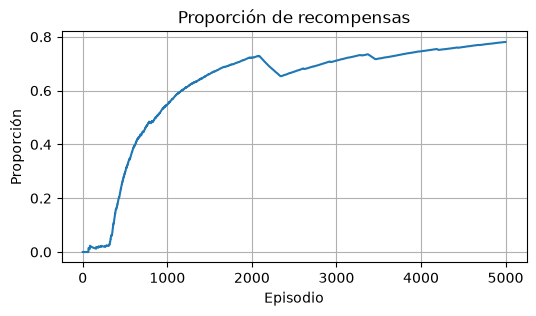

Máxima proporcion: 0.7808


In [ ]:
plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

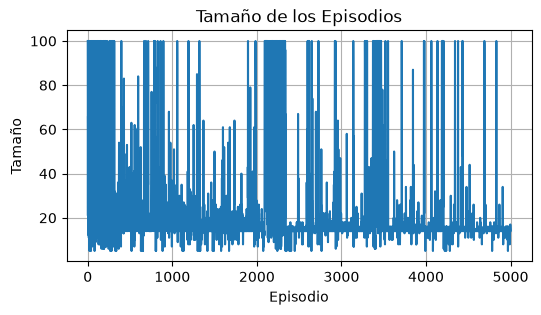

Máximo tamaño de episodio: 100


In [ ]:
plot_episodes_length(list_episodes_length)
print(f"Máximo tamaño de episodio:", max(list_episodes_length))

In [ ]:
pi, actions = pi_star_from_Q(env8, Q_net8)
print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env8.render())

Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 Acciones 2,

In [ ]:
plot_policy_episodes(Q_net8, 1)